<a href="https://colab.research.google.com/github/sig-gis/cwcb-landcover-mapping/blob/main/00_Intial_Explorations/ComputerVision_Methods_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install rasterio segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.0 MB/s eta 0:00:00


In [2]:
import json, math, random, time, requests
import numpy as np
from pathlib import Path
from rasterio.io import MemoryFile

# ---- knobs ----------------------------------------------------------------
AOI     = (-88.1676, 44.3681, -87.8480, 44.5808)  # lonmin, latmin, lonmax, latmax
RES_M   = 0.6      # requested ground sample distance (m) — imagery-native
CHIP_PX = 256      # chip size in pixels
N_CHIPS = 100
SEED    = 0
OUT     = Path("/content/chips")
# ---------------------------------------------------------------------------

NAIP = "https://imagery.nationalmap.gov/arcgis/rest/services/USGSNAIPPlus/ImageServer"
CCAP = "https://coast.noaa.gov/arcgisimg/rest/services/Landcover/CCAP_High_Resolution_V2_Landcover/ImageServer"

(OUT / "images").mkdir(parents=True, exist_ok=True)
(OUT / "masks").mkdir(parents=True, exist_ok=True)

midlat = (AOI[1] + AOI[3]) / 2
DY = CHIP_PX * RES_M / 111320.0                                      # chip height, degrees
DX = CHIP_PX * RES_M / (111320.0 * math.cos(math.radians(midlat)))  # chip width, degrees

def export(service, bbox, interpolation):
    """One exportImage call -> raw GeoTIFF bytes."""
    params = {
        "f": "image", "format": "tiff", "pixelType": "U8",
        "bbox": ",".join(f"{v:.8f}" for v in bbox),
        "bboxSR": 4326, "imageSR": 4326,
        "size": f"{CHIP_PX},{CHIP_PX}",
        "renderingRule": '{"rasterFunction":"None"}',  # raw values, no display styling
        "interpolation": interpolation,
        "adjustAspectRatio": "false",
    }
    for attempt in range(3):
        r = requests.get(service + "/exportImage", params=params, timeout=120)
        if r.ok and r.headers.get("Content-Type", "").startswith("image"):
            return r.content
        time.sleep(2 * (attempt + 1))
    raise RuntimeError(f"exportImage failed ({r.status_code}): {r.text[:200]}")

def as_array(tif_bytes):
    with MemoryFile(tif_bytes) as mf, mf.open() as src:
        return src.read()

# class value -> name from the C-CAP legend (cosmetic; codes are what we train on)
classes = {}
try:
    leg = requests.get(CCAP + "/legend", params={"f": "pjson"}, timeout=60).json()
    for e in leg["layers"][0]["legend"]:
        for v in e.get("values") or []:
            classes[int(v)] = e["label"]
except Exception as err:
    print("legend lookup failed, continuing without names:", err)
print(f"{len(classes)} named classes")

rng = random.Random(SEED)
chips, attempts = [], 0
while len(chips) < N_CHIPS and attempts < N_CHIPS * 3:
    attempts += 1
    cx = rng.uniform(AOI[0] + DX / 2, AOI[2] - DX / 2)
    cy = rng.uniform(AOI[1] + DY / 2, AOI[3] - DY / 2)
    bbox = (cx - DX / 2, cy - DY / 2, cx + DX / 2, cy + DY / 2)
    try:
        m_bytes = export(CCAP, bbox, "RSP_NearestNeighbor")
        mask = as_array(m_bytes)
        if mask.max() == 0:                       # outside C-CAP coverage
            continue
        i_bytes = export(NAIP, bbox, "RSP_BilinearInterpolation")
        img = as_array(i_bytes)
        if img.shape[0] != 4 or img.max() == 0:   # missing NIR / blank imagery
            continue
    except Exception as err:
        print("skip:", err)
        continue
    if not chips:
        print("first mask values:", np.unique(mask), "| image bands:", img.shape[0])
    cid = f"{len(chips):03d}"
    (OUT / "images" / f"{cid}.tif").write_bytes(i_bytes)
    (OUT / "masks" / f"{cid}.tif").write_bytes(m_bytes)
    chips.append({"id": cid, "bbox": list(bbox)})
    if len(chips) % 20 == 0:
        print(f"{len(chips)}/{N_CHIPS}")

json.dump(
    {"aoi": AOI, "res_m": RES_M, "chip_px": CHIP_PX, "seed": SEED,
     "services": {"image": NAIP, "mask": CCAP},
     "classes": classes, "chips": chips},
    open(OUT / "manifest.json", "w"), indent=1,
)
print(f"done: {len(chips)} chip pairs in {OUT}")

legend lookup failed, continuing without names: invalid literal for int() with base 10: 'Impervious Surface'
0 named classes
first mask values: [ 7 13] | image bands: 4
20/100
40/100
60/100
80/100
100/100
done: 100 chip pairs in /content/chips


class share across all masks:
   2  ?                                           17.9%
   3  ?                                            0.7%
   5  ?                                           19.8%
   6  ?                                           15.4%
   7  ?                                            9.8%
   8  ?                                            3.4%
  11  ?                                           12.4%
  12  ?                                            1.4%
  13  ?                                            6.0%
  14  ?                                            0.2%
  15  ?                                            2.1%
  20  ?                                            2.3%
  21  ?                                            8.5%
  22  ?                                            0.3%


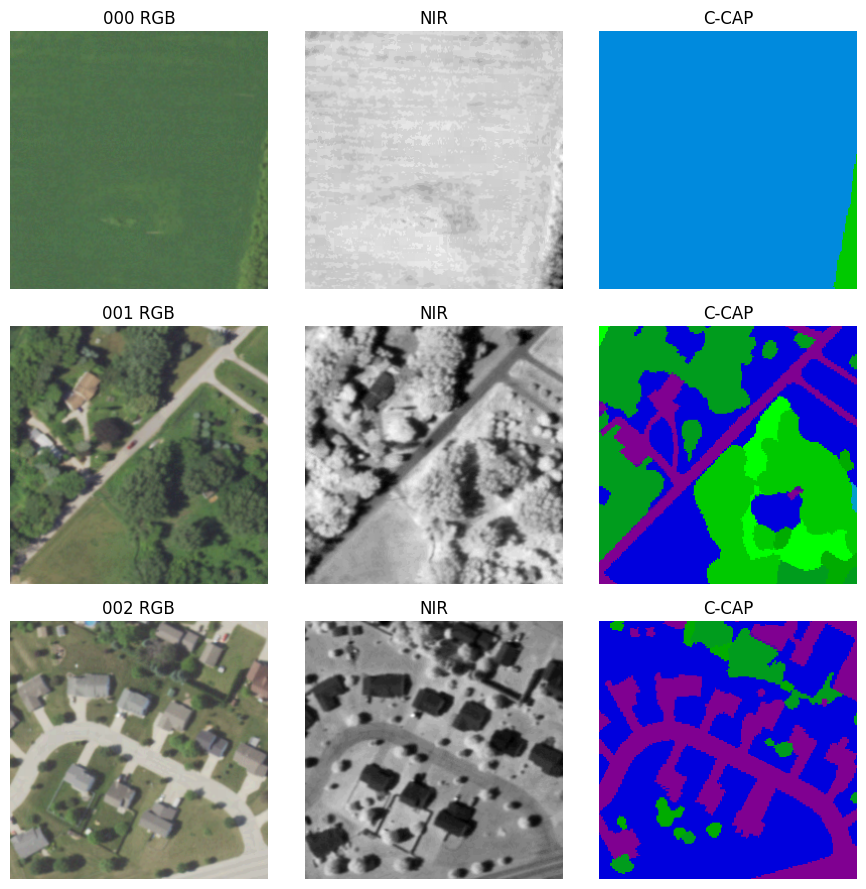

In [3]:
import json
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("/content/chips")
man = json.load(open(OUT / "manifest.json"))
ids = [c["id"] for c in man["chips"]]
name = lambda v: man["classes"].get(str(v), "?")

counts = np.zeros(26, dtype=np.int64)
for cid in ids:
    with rasterio.open(OUT / f"masks/{cid}.tif") as s:
        counts += np.bincount(s.read(1).ravel(), minlength=26)
print("class share across all masks:")
for v in np.nonzero(counts)[0]:
    print(f"  {v:2d}  {name(v):42s} {counts[v] / counts.sum():6.1%}")

fig, ax = plt.subplots(3, 3, figsize=(9, 9))
for row, cid in enumerate(ids[:3]):
    with rasterio.open(OUT / f"images/{cid}.tif") as s:
        img = s.read()
    with rasterio.open(OUT / f"masks/{cid}.tif") as s:
        m = s.read(1)
    ax[row, 0].imshow(img[:3].transpose(1, 2, 0)); ax[row, 0].set_title(f"{cid} RGB")
    ax[row, 1].imshow(img[3], cmap="gray");        ax[row, 1].set_title("NIR")
    ax[row, 2].imshow(m, cmap="nipy_spectral", vmin=0, vmax=25); ax[row, 2].set_title("C-CAP")
for a in ax.ravel():
    a.axis("off")
plt.tight_layout(); plt.show()

In [4]:
# import json
# import numpy as np
# import rasterio
# import torch
# import torch.nn as nn
# from pathlib import Path
# from torch.utils.data import Dataset, DataLoader
# import segmentation_models_pytorch as smp

# OUT       = Path("/content/chips")
# N_CLASSES = 26                 # C-CAP HR codes 0–25; 0 = background, ignored
# EPOCHS, BATCH, LR, VAL_FRAC = 15, 8, 3e-4, 0.2

# man   = json.load(open(OUT / "manifest.json"))
# chips = sorted(man["chips"], key=lambda c: c["bbox"][0])     # west -> east
# n_val = max(1, int(len(chips) * VAL_FRAC))
# train_ids = [c["id"] for c in chips[:-n_val]]
# val_ids   = [c["id"] for c in chips[-n_val:]]                # easternmost block held out
# print(f"train {len(train_ids)} / val {len(val_ids)}")

# class Chips(Dataset):
#     def __init__(self, ids): self.ids = ids
#     def __len__(self): return len(self.ids)
#     def __getitem__(self, i):
#         cid = self.ids[i]
#         with rasterio.open(OUT / f"images/{cid}.tif") as s:
#             x = torch.from_numpy(s.read().astype("float32") / 255.0)
#         with rasterio.open(OUT / f"masks/{cid}.tif") as s:
#             y = torch.from_numpy(s.read(1).astype("int64"))
#         return x, y

# train_dl = DataLoader(Chips(train_ids), batch_size=BATCH, shuffle=True)
# val_dl   = DataLoader(Chips(val_ids), batch_size=BATCH)

# # ---- THE MODEL — swap this one line; anything (B,4,H,W)->(B,N_CLASSES,H,W) works ----
# # model = smp.Unet("resnet34", encoder_weights="imagenet", in_channels=4, classes=N_CLASSES)
# # smp.DeepLabV3Plus / smp.Segformer / smp.UPerNet: identical signature. Or any nn.Module.
# # -------------------------------------------------------------------------------------

# dev   = "cuda" if torch.cuda.is_available() else "cpu"
# model = model.to(dev)
# opt   = torch.optim.Adam(model.parameters(), lr=LR)
# lossf = nn.CrossEntropyLoss(ignore_index=0)

# for ep in range(EPOCHS):
#     model.train(); tl = 0.0
#     for x, y in train_dl:
#         x, y = x.to(dev), y.to(dev)
#         opt.zero_grad()
#         loss = lossf(model(x), y)
#         loss.backward(); opt.step()
#         tl += loss.item() * len(x)

#     model.eval()
#     cm = np.zeros((N_CLASSES, N_CLASSES), dtype=np.int64)
#     with torch.no_grad():
#         for x, y in val_dl:
#             p = model(x.to(dev)).argmax(1).cpu().numpy().ravel()
#             t = y.numpy().ravel()
#             k = t > 0
#             cm += np.bincount(t[k] * N_CLASSES + p[k], minlength=N_CLASSES ** 2
#                               ).reshape(N_CLASSES, N_CLASSES)
#     inter = np.diag(cm)
#     union = cm.sum(0) + cm.sum(1) - inter
#     valid = union > 0
#     valid[0] = False
#     iou = inter[valid] / union[valid]
#     print(f"epoch {ep + 1:2d}   train_loss {tl / len(train_ids):.3f}   "
#           f"val_acc {inter.sum() / max(cm.sum(), 1):.3f}   val_mIoU {iou.mean():.3f}")

# print("\nper-class IoU (val, final epoch):")
# name = lambda v: man["classes"].get(str(v), "?")
# for v in np.nonzero(valid)[0]:
#     print(f"  {v:2d}  {name(v):42s} {inter[v] / union[v]:.3f}")

In [5]:
# import random
# import matplotlib.pyplot as plt
# import torch

# model.eval()
# ds = Chips(val_ids)
# picks = random.sample(range(len(ds)), min(3, len(ds)))   # rerun cell for a new draw
# fig, ax = plt.subplots(3, 3, figsize=(9, 9))
# for row, i in enumerate(picks):
#     cid = ds.ids[i]
#     x, y = ds[i]
#     with torch.no_grad():
#         p = model(x[None].to(dev)).argmax(1)[0].cpu().numpy()
#     ax[row, 0].imshow(x[:3].numpy().transpose(1, 2, 0)); ax[row, 0].set_title(f"{cid} RGB")
#     ax[row, 1].imshow(y.numpy(), cmap="nipy_spectral", vmin=0, vmax=25); ax[row, 1].set_title("C-CAP")
#     ax[row, 2].imshow(p, cmap="nipy_spectral", vmin=0, vmax=25); ax[row, 2].set_title("prediction")
# for a in ax.ravel():
#     a.axis("off")
# plt.tight_layout(); plt.show()

In [6]:
!pip -q install rasterio segmentation-models-pytorch ultralytics
from google.colab import drive
drive.mount("/content/drive")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.8 MB/s eta 0:00:00
Mounted at /content/drive


In [7]:
import json, math, random, time, requests
import numpy as np
from pathlib import Path
from rasterio.io import MemoryFile

NAIP = "https://imagery.nationalmap.gov/arcgis/rest/services/USGSNAIPPlus/ImageServer"
CCAP = "https://coast.noaa.gov/arcgisimg/rest/services/Landcover/CCAP_High_Resolution_V2_Landcover/ImageServer"

def export(service, bbox, size, interpolation):
    params = {
        "f": "image", "format": "tiff", "pixelType": "U8",
        "bbox": ",".join(f"{v:.8f}" for v in bbox),
        "bboxSR": 4326, "imageSR": 4326, "size": f"{size},{size}",
        "renderingRule": '{"rasterFunction":"None"}',
        "interpolation": interpolation, "adjustAspectRatio": "false",
    }
    for attempt in range(3):
        r = requests.get(service + "/exportImage", params=params, timeout=120)
        if r.ok and r.headers.get("Content-Type", "").startswith("image"):
            return r.content
        time.sleep(2 * (attempt + 1))
    raise RuntimeError(f"exportImage failed ({r.status_code}): {r.text[:200]}")

def as_array(b):
    with MemoryFile(b) as mf, mf.open() as src:
        return src.read()

def pull(aoi, out, n_chips=100, res_m=0.6, chip_px=256, seed=0):
    out = Path(out)
    (out / "images").mkdir(parents=True, exist_ok=True)
    (out / "masks").mkdir(parents=True, exist_ok=True)
    dy = chip_px * res_m / 111320.0
    dx = chip_px * res_m / (111320.0 * math.cos(math.radians((aoi[1] + aoi[3]) / 2)))

    classes = {}
    try:
        leg = requests.get(CCAP + "/legend", params={"f": "pjson"}, timeout=60).json()
        for e in leg["layers"][0]["legend"]:
            for v in e.get("values") or []:
                classes[int(v)] = e["label"]
    except Exception as err:
        print("legend lookup failed, continuing without names:", err)

    rng, chips, attempts = random.Random(seed), [], 0
    while len(chips) < n_chips and attempts < n_chips * 3:
        attempts += 1
        cx = rng.uniform(aoi[0] + dx / 2, aoi[2] - dx / 2)
        cy = rng.uniform(aoi[1] + dy / 2, aoi[3] - dy / 2)
        bbox = (cx - dx / 2, cy - dy / 2, cx + dx / 2, cy + dy / 2)
        try:
            m_bytes = export(CCAP, bbox, chip_px, "RSP_NearestNeighbor")
            m_arr = as_array(m_bytes)
            if m_arr.max() == 0:                      # outside C-CAP coverage
                continue
            i_bytes = export(NAIP, bbox, chip_px, "RSP_BilinearInterpolation")
            img = as_array(i_bytes)
            if img.shape[0] != 4 or img.max() == 0:   # missing NIR / blank imagery
                continue
        except Exception as err:
            print("skip:", err)
            continue
        if not chips:
            print("first mask values:", np.unique(m_arr), "| image bands:", img.shape[0])
        cid = f"{len(chips):03d}"
        (out / "images" / f"{cid}.tif").write_bytes(i_bytes)
        (out / "masks" / f"{cid}.tif").write_bytes(m_bytes)
        chips.append({"id": cid, "bbox": list(bbox)})
        if len(chips) % 20 == 0:
            print(f"{len(chips)}/{n_chips}")

    json.dump({"aoi": list(aoi), "res_m": res_m, "chip_px": chip_px, "seed": seed,
               "services": {"image": NAIP, "mask": CCAP},
               "classes": classes, "chips": chips},
              open(out / "manifest.json", "w"), indent=1)
    print(f"done: {len(chips)} chip pairs in {out}")

# De Pere–Allouez–Bellevue corridor: suburban Green Bay, inside the Part 1 AOI
SUB_AOI = (-88.07, 44.43, -87.95, 44.50)
pull(SUB_AOI, "/content/chips_suburban", n_chips=200, res_m=0.6, chip_px=512, seed=1)

legend lookup failed, continuing without names: invalid literal for int() with base 10: 'Impervious Surface'
first mask values: [ 2  3  5 11 20 21] | image bands: 4
20/200
40/200
60/200
80/200
skip: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))
100/200
120/200
140/200
160/200
180/200
200/200
done: 200 chip pairs in /content/chips_suburban


In [8]:
import json
import numpy as np
import rasterio
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

DATA      = Path("/content/chips_suburban")
N_CLASSES = 26                 # C-CAP HR codes 0-25; 0 = background, ignored
EPOCHS, BATCH, LR, VAL_FRAC = 20, 8, 3e-4, 0.2
dev = "cuda" if torch.cuda.is_available() else "cpu"

man   = json.load(open(DATA / "manifest.json"))
chips = sorted(man["chips"], key=lambda c: c["bbox"][0])     # west -> east
n_val = max(1, int(len(chips) * VAL_FRAC))
train_ids = [c["id"] for c in chips[:-n_val]]
val_ids   = [c["id"] for c in chips[-n_val:]]                # easternmost block held out
print(f"train {len(train_ids)} / val {len(val_ids)}")

def load(cid):
    with rasterio.open(DATA / f"images/{cid}.tif") as s:
        x = s.read().astype("float32") / 255.0
    with rasterio.open(DATA / f"masks/{cid}.tif") as s:
        y = s.read(1).astype("int64")
    return x, y

class Chips(Dataset):
    def __init__(self, ids): self.ids = ids
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        x, y = load(self.ids[i])
        return torch.from_numpy(x), torch.from_numpy(y)

def train_one(model):
    model = model.to(dev)
    dl    = DataLoader(Chips(train_ids), batch_size=BATCH, shuffle=True)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    lossf = nn.CrossEntropyLoss(ignore_index=0)
    for ep in range(EPOCHS):
        model.train(); tl = 0.0
        for x, y in dl:
            x, y = x.to(dev), y.to(dev)
            opt.zero_grad()
            loss = lossf(model(x), y)
            loss.backward(); opt.step()
            tl += loss.item() * len(x)
        print(f"  epoch {ep + 1:2d}  loss {tl / len(train_ids):.3f}")
    return model

def predict_stack(model, ids):
    model.eval(); out = []
    with torch.no_grad():
        for cid in ids:
            x, _ = load(cid)
            p = model(torch.from_numpy(x)[None].to(dev)).argmax(1)[0].cpu().numpy()
            out.append(p.astype(np.uint8))
    return np.stack(out)

# add/remove entries freely; anything (B,4,H,W)->(B,N_CLASSES,H,W) slots in
MODELS = {
    "unet_r34":     lambda: smp.Unet("resnet34", encoder_weights="imagenet",
                                     in_channels=4, classes=N_CLASSES),
    "segformer_b0": lambda: smp.Segformer("mit_b0", encoder_weights="imagenet",
                                          in_channels=4, classes=N_CLASSES),
}
preds = {}
for mname, make in MODELS.items():
    print(f"== {mname}")
    preds[mname] = predict_stack(train_one(make()), val_ids)

train 160 / val 40
== unet_r34


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

  epoch  1  loss 3.138
  epoch  2  loss 2.448
  epoch  3  loss 2.078
  epoch  4  loss 1.760
  epoch  5  loss 1.548
  epoch  6  loss 1.401
  epoch  7  loss 1.213
  epoch  8  loss 1.128
  epoch  9  loss 1.033
  epoch 10  loss 0.990
  epoch 11  loss 1.004
  epoch 12  loss 0.883
  epoch 13  loss 0.880
  epoch 14  loss 0.857
  epoch 15  loss 0.852
  epoch 16  loss 0.797
  epoch 17  loss 0.798
  epoch 18  loss 0.726
  epoch 19  loss 0.695
  epoch 20  loss 0.695
== segformer_b0


config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

  epoch  1  loss 1.980
  epoch  2  loss 1.129
  epoch  3  loss 0.957
  epoch  4  loss 0.919
  epoch  5  loss 0.852
  epoch  6  loss 0.817
  epoch  7  loss 0.794
  epoch  8  loss 0.776
  epoch  9  loss 0.735
  epoch 10  loss 0.704
  epoch 11  loss 0.674
  epoch 12  loss 0.672
  epoch 13  loss 0.682
  epoch 14  loss 0.633
  epoch 15  loss 0.627
  epoch 16  loss 0.611
  epoch 17  loss 0.599
  epoch 18  loss 0.553
  epoch 19  loss 0.533
  epoch 20  loss 0.511


In [9]:
import torch.nn.functional as Fn
from ultralytics import SAM

SAM_WEIGHTS = "sam2.1_b.pt"           # sam2.1_t/s/b/l.pt all valid, auto-download
ENC_LR, HEAD_LR = 3e-5, 3e-4          # pretrained encoder fine-tunes 10x slower than the new head

enc   = SAM(SAM_WEIGHTS).model.image_encoder.to(dev)
stock = SAM(SAM_WEIGHTS).model.image_encoder      # untouched reference build, CPU

def _feats(o):
    """Multiscale feature list regardless of encoder return format."""
    if isinstance(o, dict):
        o = o.get("backbone_fpn") or [v for v in o.values() if torch.is_tensor(v) and v.ndim == 4]
    return list(o) if isinstance(o, (list, tuple)) else [o]

def fdelta(a, b):
    """Mean |feature difference| between two inputs, averaged over FPN levels."""
    fa, fb = _feats(enc(a)), _feats(enc(b))
    return sum((u - v).abs().mean().item() for u, v in zip(fa, fb)) / len(fa)

# --- widen SAM's patch embed from RGB to RGBN --------------------------------
stem = None
for nm, m in enc.named_modules():
    if isinstance(m, nn.Conv2d) and m.in_channels == 3:
        stem = m
        break
assert stem is not None, "no 3-channel conv found in encoder"
w = stem.weight.detach()
stem.weight = nn.Parameter(torch.cat([w, w.mean(1, keepdim=True)], 1) * (3 / 4))
stem.in_channels = 4
rgb0 = stem.weight[:, :3].detach().clone()        # init snapshots for the post-training
nir0 = stem.weight[:, 3].detach().clone()         # drift measurement

# --- exhaustive diff against the stock checkpoint ----------------------------
leaves = [(na, ma, mb) for (na, ma), (_, mb) in zip(stock.named_modules(), enc.named_modules())
          if not list(ma.children())]
diff = [(na, ma, mb) for na, ma, mb in leaves if repr(ma) != repr(mb)]
print(f"leaf modules differing from stock checkpoint: {len(diff)} of {len(leaves)}")
for na, ma, mb in diff:
    print(f"  {na}\n    stock:    {ma}\n    modified: {mb}")

pa, pb = dict(stock.named_parameters()), dict(enc.named_parameters())
changed = [k for k in pa if pa[k].shape != pb[k].shape]
print(f"parameters with changed shape: {len(changed)} of {len(pa)}")
for k in changed:
    print(f"  {k}: {tuple(pa[k].shape)} -> {tuple(pb[k].shape)}")
identical = all(torch.equal(pa[k], pb[k].detach().cpu()) for k in pa if k not in changed)
print(f"remaining {len(pa) - len(changed)} parameters bit-identical to checkpoint: {identical}")
ws, wm = pa[changed[0]], pb[changed[0]].detach().cpu()
print("modified[:, :3] == stock * 3/4:", torch.allclose(wm[:, :3], ws * 0.75),
      "  modified[:, 3] == stock RGB-mean * 3/4:", torch.allclose(wm[:, 3], ws.mean(1) * 0.75))
del stock, pa, pb

# --- functional probes --------------------------------------------------------
enc.eval()
with torch.no_grad():
    try:                                          # a true RGBN stem must now refuse RGB
        enc(torch.zeros(1, 3, man["chip_px"], man["chip_px"], device=dev))
        print("3-band probe: ACCEPTED -- adaptation failed")
    except RuntimeError:
        print("3-band probe: rejected (stem requires 4 channels)")
    x0 = torch.from_numpy(load(train_ids[0])[0])[None].to(dev)
    xn = x0.clone(); xn[:, 3] = 0                 # same chip, NIR deleted
    xr = x0.clone(); xr[:, 0] = 0                 # same chip, red deleted, for scale
    print(f"feature shift from zeroing one band   NIR {fdelta(x0, xn):.4f}   red {fdelta(x0, xr):.4f}")
    probe = enc(torch.zeros(1, 4, man["chip_px"], man["chip_px"], device=dev))
print("encoder output pyramid (C, H, W):", [tuple(f.shape[1:]) for f in _feats(probe)])
chans = [f.shape[1] for f in _feats(probe)]

class SamSeg(nn.Module):
    """SAM2 image encoder + FPN-fuse semantic head -> per-pixel class logits."""
    def __init__(self, encoder, chans, n_classes, width=128):
        super().__init__()
        self.encoder = encoder
        self.lat  = nn.ModuleList([nn.Conv2d(c, width, 1) for c in chans])
        self.fuse = nn.Sequential(nn.Conv2d(width, width, 3, padding=1), nn.ReLU(inplace=True),
                                  nn.Conv2d(width, width, 3, padding=1), nn.ReLU(inplace=True))
        self.head = nn.Conv2d(width, n_classes, 1)

    def forward(self, x):
        feats = _feats(self.encoder(x))
        tgt = max((f.shape[-2:] for f in feats), key=lambda s: s[0] * s[1])
        z = sum(Fn.interpolate(lat(f), size=tgt, mode="bilinear", align_corners=False)
                for lat, f in zip(self.lat, feats))
        return Fn.interpolate(self.head(self.fuse(z)), size=x.shape[-2:],
                              mode="bilinear", align_corners=False)

model = SamSeg(enc, chans, N_CLASSES).to(dev)
opt = torch.optim.Adam([
    {"params": model.encoder.parameters(), "lr": ENC_LR},
    {"params": [p for n, p in model.named_parameters() if not n.startswith("encoder.")],
     "lr": HEAD_LR},
])
lossf = nn.CrossEntropyLoss(ignore_index=0)
dl = DataLoader(Chips(train_ids), batch_size=BATCH, shuffle=True)

for ep in range(EPOCHS):
    model.train(); tl = 0.0
    for x, y in dl:
        x, y = x.to(dev), y.to(dev)
        opt.zero_grad()
        loss = lossf(model(x), y)
        loss.backward(); opt.step()
        tl += loss.item() * len(x)
    print(f"  epoch {ep + 1:2d}  loss {tl / len(train_ids):.3f}")

d_nir = ((stem.weight[:, 3] - nir0).norm() / nir0.norm()).item()
d_rgb = ((stem.weight[:, :3] - rgb0).norm() / rgb0.norm()).item()
print(f"stem kernel drift since init   NIR {d_nir:.1%}   RGB {d_rgb:.1%}")

preds["sam2_finetuned"] = predict_stack(model, val_ids)

def predict_ablate(mode):
    """Val predictions with the NIR band destroyed at inference time."""
    model.eval(); outs = []
    g = torch.Generator().manual_seed(0)
    for cid in val_ids:
        x = torch.from_numpy(load(cid)[0])
        if mode == "zero":
            x[3] = 0
        else:                                     # scramble: keep marginal stats, kill alignment
            flat = x[3].flatten()
            x[3] = flat[torch.randperm(flat.numel(), generator=g)].reshape(x[3].shape)
        with torch.no_grad():
            outs.append(model(x[None].to(dev)).argmax(1)[0].cpu().numpy().astype(np.uint8))
    return np.stack(outs)

preds["sam2_ft_nir_zero"]     = predict_ablate("zero")
preds["sam2_ft_nir_scramble"] = predict_ablate("scramble")
print("sam2_finetuned + NIR ablations done -- re-run Cell 10 to rescore")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
leaf modules differing from stock checkpoint: 1 of 228
  trunk.patch_embed.proj
    stock:    Conv2d(3, 112, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
    modified: Conv2d(4, 112, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
parameters with changed shape: 1 of 306
  trunk.patch_embed.proj.weight: (112, 3, 7, 7) -> (112, 4, 7, 7)
remaining 305 parameters bit-identical to checkpoint: True
modified[:, :3] == stock * 3/4: True   modified[:, 3] == stock RGB-mean * 3/4: True
3-band probe: rejected (stem requires 4 channels)
feature shift from zeroing one band   NIR 0.0296   red 0.0344
encoder output pyramid (C, H, W): [(256, 128, 128), (256, 64, 64), (256, 32, 32)]
  epoc

In [10]:
# model = SamSeg(enc, chans, N_CLASSES).to(dev)
opt = torch.optim.Adam([
    {"params": model.encoder.parameters(), "lr": ENC_LR},
    {"params": [p for n, p in model.named_parameters() if not n.startswith("encoder.")],
     "lr": HEAD_LR},
])
lossf = nn.CrossEntropyLoss(ignore_index=0)
dl = DataLoader(Chips(train_ids), batch_size=BATCH, shuffle=True)

for ep in range(EPOCHS):
    model.train(); tl = 0.0
    for x, y in dl:
        x, y = x.to(dev), y.to(dev)
        opt.zero_grad()
        loss = lossf(model(x), y)
        loss.backward(); opt.step()
        tl += loss.item() * len(x)
    print(f"  epoch {ep + 1:2d}  loss {tl / len(train_ids):.3f}")

d_nir = ((stem.weight[:, 3] - nir0).norm() / nir0.norm()).item()
d_rgb = ((stem.weight[:, :3] - rgb0).norm() / rgb0.norm()).item()
print(f"stem kernel drift since init   NIR {d_nir:.1%}   RGB {d_rgb:.1%}")

preds["sam2_finetuned"] = predict_stack(model, val_ids)
print("sam2_finetuned done -- re-run Cell 10 to rescore")

  epoch  1  loss 0.590
  epoch  2  loss 0.536
  epoch  3  loss 0.530
  epoch  4  loss 0.501
  epoch  5  loss 0.482
  epoch  6  loss 0.476
  epoch  7  loss 0.502
  epoch  8  loss 0.478
  epoch  9  loss 0.455
  epoch 10  loss 0.437
  epoch 11  loss 0.420
  epoch 12  loss 0.407
  epoch 13  loss 0.407
  epoch 14  loss 0.401
  epoch 15  loss 0.395
  epoch 16  loss 0.382
  epoch 17  loss 0.378
  epoch 18  loss 0.367
  epoch 19  loss 0.368
  epoch 20  loss 0.363
stem kernel drift since init   NIR 5.9%   RGB 2.5%
sam2_finetuned done -- re-run Cell 10 to rescore


model                   acc   mIoU
unet_r34              0.678  0.297
segformer_b0          0.686  0.279
sam2_finetuned        0.695  0.292
sam2_ft_nir_zero      0.548  0.148
sam2_ft_nir_scramble  0.473  0.142

      unet_r34  segformer_b0  sam2_finetuned  sam2_ft_nir_zero  \
02 ?     0.757         0.780           0.789             0.638   
03 ?     0.000         0.004           0.017             0.000   
05 ?     0.558         0.590           0.615             0.390   
06 ?     0.696         0.517           0.725             0.202   
07 ?     0.000         0.003           0.066             0.042   
08 ?     0.092         0.105           0.106             0.038   
11 ?     0.497         0.519           0.483             0.463   
12 ?     0.000         0.054           0.095             0.000   
13 ?     0.340         0.267           0.279             0.190   
14 ?     0.000         0.000           0.000             0.000   
15 ?     0.239         0.244           0.143             0.039 

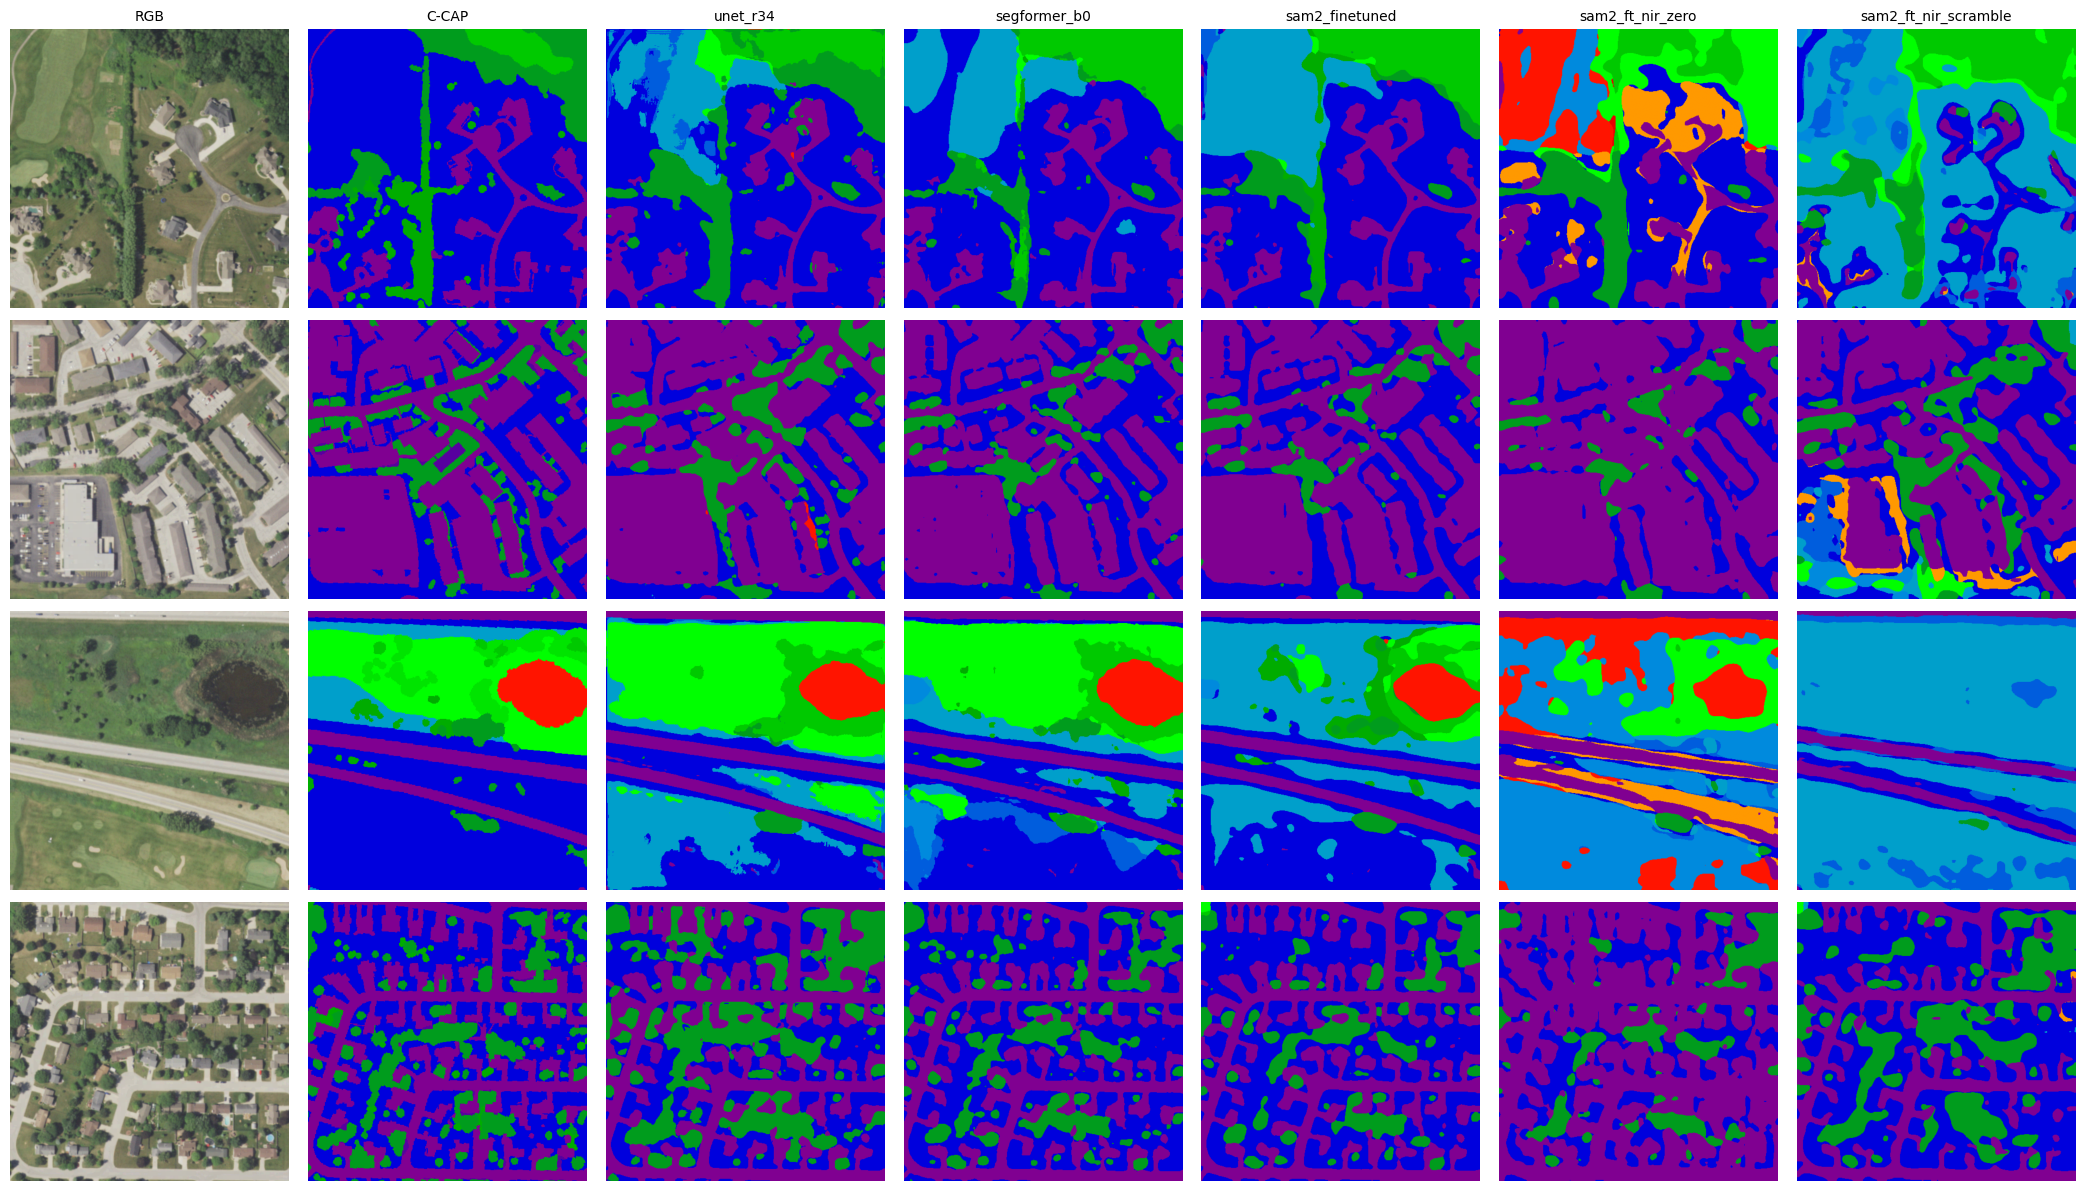


results saved to /content/drive/MyDrive/naip_ccap_seg_results/20260612_215816


In [11]:
import random
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

truth = np.stack([load(c)[1] for c in val_ids])
name  = lambda v: man["classes"].get(str(v), "?")

def score(pred):
    k = truth > 0
    cm = np.bincount(truth[k] * N_CLASSES + pred[k], minlength=N_CLASSES ** 2
                     ).reshape(N_CLASSES, N_CLASSES)
    inter = np.diag(cm); union = cm.sum(0) + cm.sum(1) - inter
    valid = union > 0; valid[0] = False
    per = {int(v): float(inter[v] / union[v]) for v in np.nonzero(valid)[0]}
    return {"acc": float(inter.sum() / max(cm.sum(), 1)),
            "miou": float(np.mean(list(per.values()))), "per_class": per}

scores = {m: score(p) for m, p in preds.items()}
print(f"{'model':20s} {'acc':>6s} {'mIoU':>6s}")
for m, s in scores.items():
    print(f"{m:20s} {s['acc']:6.3f} {s['miou']:6.3f}")

iou = pd.DataFrame({m: s["per_class"] for m, s in scores.items()}).sort_index()
iou.index = [f"{v:02d} {name(v)}" for v in iou.index]
print(); print(iou.round(3))

rows = random.sample(range(len(val_ids)), min(4, len(val_ids)))
cols = ["RGB", "C-CAP"] + list(preds)
fig, ax = plt.subplots(len(rows), len(cols), figsize=(3 * len(cols), 3 * len(rows)))
ax = np.atleast_2d(ax)
for r, i in enumerate(rows):
    x, _ = load(val_ids[i])
    panels = [None, truth[i]] + [preds[m][i] for m in preds]
    ax[r, 0].imshow(x[:3].transpose(1, 2, 0))
    for c in range(1, len(cols)):
        ax[r, c].imshow(panels[c], cmap="nipy_spectral", vmin=0, vmax=25)
    for c, t in enumerate(cols):
        ax[r, c].set_title(t if r == 0 else "", fontsize=10)
        ax[r, c].axis("off")
plt.tight_layout()

out = Path(f"/content/drive/MyDrive/naip_ccap_seg_results/{datetime.now():%Y%m%d_%H%M%S}")
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "comparison.png", dpi=150, bbox_inches="tight")
plt.show()
json.dump({"data": str(DATA), "aoi": man["aoi"], "res_m": man["res_m"],
           "chip_px": man["chip_px"], "train": len(train_ids), "val": len(val_ids),
           "epochs": EPOCHS, "scores": scores},
          open(out / "metrics.json", "w"), indent=1)
iou.to_csv(out / "per_class_iou.csv")
np.savez_compressed(out / "val_predictions.npz",
                    truth=truth, ids=np.array(val_ids), **preds)
(out / "manifest.json").write_text((DATA / "manifest.json").read_text())
print("\nresults saved to", out)